# Análise de Tráfego de Rede 2025/26 
## TP2 - Anonimização de Tráfego e Deteção de Anonimizadores


### Grupo 04

<p style="font-size: 0.9em;">
Carlos Daniel Silva Fernandes - PG59783
</p>

<p style="font-size: 0.9em;">
Luís Filipe Pinheiro Silva - PG59790
</p>


<p style="font-size: 0.9em;">
Pedro Augusto Ennes de Martino Camargo - PG59791
</p>

---

## Introdução

O presente trabalho tem como objetivo estudar o equilíbrio entre privacidade e utilidade, através da aplicação de diferentes técnicas de anonimização a um dataset de tráfego de rede. Numa primeira fase, são geradas múltiplas versões anonimizadas do dataset, recorrendo a diferentes estratégias, incluindo anonimização total e preservação de prefixos. Posteriormente, são avaliadas métricas quantitativas como a entropia de Shannon e o k-anonymity, de forma a medir o impacto dessas transformações.

Numa segunda fase, é desenvolvido um classificador capaz de identificar tráfego associado a tecnologias de anonimização, como VPNs e Tor, utilizando apenas características estatísticas do fluxo. A análise dos resultados permite compreender até que ponto a anonimização afeta a capacidade de deteção, evidenciando o equilíbrio necessário entre proteção de dados e eficácia operacional.

In [18]:
from pathlib import Path
import hashlib
import random
import os
import pandas as pd
import subprocess

NORMAL_DIR  = "pcaps/normal"
VPN_DIR     = "pcaps/vpn"
OUTPUT_CSV  = "csvs/merged_flows.csv"


def run_zeek(pcap_path: str) -> None:
    log_dir = f"zeek_logs/{os.path.basename(pcap_path).replace('.pcap','')}"
    os.makedirs(log_dir, exist_ok=True)

    if not os.path.exists(pcap_path):
        print(f"File not found: {pcap_path}")
        return 
    
    result = subprocess.run(
        ["zeek", "-C", "-r", pcap_path, f"Log::default_logdir={log_dir}"],
        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    if result.returncode != 0:
        print(f"[WARN] Zeek error on {pcap_path}:\n{result.stderr}")


def load_conn_log(log_dir: str) -> pd.DataFrame:
    log_path = Path(log_dir) / "conn.log"
    if not log_path.exists():
        return pd.DataFrame()

    headers = []
    rows = []

    with open(log_path) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("#fields"):
                headers = line.split("\t")[1:]
            elif line.startswith("#"):
                continue
            else:
                rows.append(line.split("\t"))

    if not headers or not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows, columns=headers)
    return df


def process_directory(pcap_dir: str, label: str) -> pd.DataFrame:
    frames = []
    pcap_dir_path = Path(pcap_dir)

    for pcap_file in sorted(pcap_dir_path.glob("*.pcap")):
        print(f"[{label}] Processing {pcap_file.name} …")
        run_zeek(str(pcap_file))

        df = load_conn_log(f"zeek_logs/{os.path.basename(pcap_file).replace('.pcap','')}")
        if df.empty:
            print(f"  ↳ no conn.log produced, skipping")
            continue

        df["source_file"] = pcap_file.name
        df["traffic_label"] = label
        frames.append(df)
        print(f"  ↳ {len(df):,} connections loaded")

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_pd():
    vpn_df    = process_directory(VPN_DIR,    label="vpn")
    normal_df = process_directory(NORMAL_DIR, label="normal")

    merged = pd.concat([vpn_df, normal_df], ignore_index=True)

    if merged.empty:
        print("No data collected – check your Zeek installation and pcap paths.")
        return

    merged.replace("-", pd.NA, inplace=True)
    merged.drop_duplicates(inplace=True)
    merged.reset_index(drop=True, inplace=True)

    merged.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✓ Merged {len(merged):,} rows → {OUTPUT_CSV}")
    print(merged[["ts", "id.orig_h", "id.resp_h", "proto",
                  "traffic_label", "source_file"]].head(10).to_string(index=False))

load_pd()

[vpn] Processing vpn_aim_chat1a.pcap …
  ↳ 29 connections loaded
[vpn] Processing vpn_aim_chat1b.pcap …
  ↳ 15 connections loaded
[vpn] Processing vpn_bittorrent.pcap …
  ↳ 493 connections loaded
[vpn] Processing vpn_email2a.pcap …
  ↳ 160 connections loaded
[vpn] Processing vpn_email2b.pcap …
  ↳ 159 connections loaded
[vpn] Processing vpn_facebook_audio2.pcap …
  ↳ 1,514 connections loaded
[vpn] Processing vpn_facebook_chat1a.pcap …
  ↳ 598 connections loaded
[vpn] Processing vpn_facebook_chat1b.pcap …
  ↳ 578 connections loaded
[vpn] Processing vpn_ftps_A.pcap …
  ↳ 78 connections loaded
[vpn] Processing vpn_ftps_B.pcap …
  ↳ 53 connections loaded
[vpn] Processing vpn_hangouts_audio1.pcap …
  ↳ 3,238 connections loaded
[vpn] Processing vpn_hangouts_audio2.pcap …
  ↳ 5,059 connections loaded
[vpn] Processing vpn_hangouts_chat1a.pcap …
  ↳ 1,295 connections loaded
[vpn] Processing vpn_hangouts_chat1b.pcap …
  ↳ 1,495 connections loaded
[normal] Processing aim_chat_3a.pcap …
  ↳ 47 con

## 1. Pipeline de Anonimização e Métricas de Dispersão

### 1.1 N1 — Anonimização Básica

Nesta fase, foi implementado um mecanismo de anonimização total dos endereços IP, com o objetivo de eliminar qualquer relação direta entre os endereços originais e os respetivos valores anonimizados.

A abordagem adotada baseia-se na aplicação de uma função determinística para transformar cada endereço IP num novo valor pseudoaleatório. Desta forma, garante-se que o mesmo IP de entrada origina sempre o mesmo IP anonimizado, assegurando consistência ao longo do dataset.

Esta técnica apresenta as seguintes vantagens:
- **Consistência**: o mesmo endereço IP é sempre mapeado para o mesmo valor anonimizado;
- **Elevado nível de anonimização**: impede a recuperação direta dos valores originais;
- **Eficiência**: elimina a necessidade de manter tabelas de correspondência em memória.



### Validação dos Resultados
A validação foi realizada utilizando a ferramenta **Tshark**, permitindo extrair e comparar os endereços IP únicos antes e depois da anonimização.

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th>#</th>
      <th>id.orig_h</th>
      <th>id.resp_h</th>
      <th>id.anon_orig_h</th>
      <th>id.anon_resp_h</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>10.8.8.178</td>
      <td>157.55.235.153</td>
      <td>13.192.6.218</td>
      <td>173.13.83.235</td>
    </tr>
    <tr>
      <th>2</th>
      <td>10.8.8.178</td>
      <td>157.55.130.172</td>
      <td>13.192.6.218</td>
      <td>231.124.30.4</td>
    </tr>
    <tr>
      <th>3</th>
      <td>10.8.8.178</td>
      <td>137.117.177.33</td>
      <td>13.192.6.218</td>
      <td>3.84.47.142</td>
    </tr>
    <tr>
      <th>4</th>
      <td>10.8.8.178</td>
      <td>198.7.63.141</td>
      <td>13.192.6.218</td>
      <td>33.97.44.36</td>
    </tr>
    <tr>
      <th>5</th>
      <td>10.8.8.178</td>
      <td>78.46.223.24</td>
      <td>13.192.6.218</td>
      <td>137.149.149.203</td>
    </tr>
    <tr>
      <th>6</th>
      <td>10.8.8.178</td>
      <td>198.7.63.141</td>
      <td>13.192.6.218</td>
      <td>33.97.44.36</td>
    </tr>
    <tr>
      <th>7</th>
      <td>10.8.8.178</td>
      <td>157.55.56.153</td>
      <td>13.192.6.218</td>
      <td>211.65.126.238</td>
    </tr>
    <tr>
      <th>8</th>
      <td>10.8.8.178</td>
      <td>157.55.235.142</td>
      <td>13.192.6.218</td>
      <td>187.188.100.85</td>
    </tr>
    <tr>
      <th>9</th>
      <td>10.8.8.178</td>
      <td>111.221.74.41</td>
      <td>13.192.6.218</td>
      <td>109.69.63.193</td>
    </tr>
    <tr>
      <th>10</th>
      <td>10.8.8.178</td>
      <td>64.4.23.162</td>
      <td>13.192.6.218</td>
      <td>192.160.187.152</td>
    </tr>
  </tbody>
</table>
</div>

In [19]:
def anonymizeIp(ip):
    h = hashlib.sha256(ip.encode()).digest()
    return ".".join(str(b % 254 + 1) for b in h[:4])

df_N1 = pd.read_csv("csvs/merged_flows.csv")

df_N1["id.anon_orig_h"] = df_N1["id.orig_h"].astype(str).map(anonymizeIp)
df_N1["id.anon_resp_h"] = df_N1["id.resp_h"].astype(str).map(anonymizeIp)

### 1.2 N2 — Prefix-Preserving

Neste nível, a anonimização dos IP's passa a ser determinística e passamos a utilizar *prefix preservation* para manter as relações entre IP's oriundos das mesmas redes e sub-redes.

De forma a implementar o N2, utilizamos a biblioteca `yacryptopan` para anonimizar IPs preservando a estrutura de rede. Foram implementadas duas variantes: uma preservando os primeiros 16 bits e outra os primeiros 24 bits. Isto permite que a análise de topologia de rede (como a identificação de sub-redes comuns) permaneça viável, mantendo a consistência entre endereços da mesma infraestrutura.


### Validação dos Resultados

N2 para /16

| #  | id.orig_h   | id.anon_orig_h | id.resp_h       | id.anon_resp_h   |
|----|-------------|----------------|-----------------|------------------|
| 1  | 10.8.8.178  | 10.8.246.145   | 157.55.235.153  | 157.55.107.94    |
| 2  | 10.8.8.178  | 10.8.246.145   | 157.55.130.172  | 157.55.13.109    |
| 3  | 10.8.8.178  | 10.8.246.145   | 137.117.177.33  | 137.117.208.194  |
| 4  | 10.8.8.178  | 10.8.246.145   | 198.7.63.141    | 198.7.35.75      |
| 5  | 10.8.8.178  | 10.8.246.145   | 78.46.223.24    | 78.46.24.22      |
| 6  | 10.8.8.178  | 10.8.246.145   | 198.7.63.141    | 198.7.35.75      |
| 7  | 10.8.8.178  | 10.8.246.145   | 157.55.56.153   | 157.55.199.111   |
| 8  | 10.8.8.178  | 10.8.246.145   | 157.55.235.142  | 157.55.107.73    |
| 9  | 10.8.8.178  | 10.8.246.145   | 111.221.74.41   | 111.221.130.11   |
| 10 | 10.8.8.178  | 10.8.246.145   | 64.4.23.162     | 64.4.232.93      |



N2 para /24

| #  | id.orig_h   | id.anon_orig_h | id.resp_h       | id.anon_resp_h   |
|----|-------------|----------------|-----------------|------------------|
| 1  |  10.8.8.178 | 10.8.8.145     | 157.55.235.153  | 157.55.235.94    |
| 2  |  10.8.8.178 | 10.8.8.145     | 157.55.130.172  | 157.55.130.109   |
| 3  |  10.8.8.178 | 10.8.8.145     | 137.117.177.33  | 137.117.177.194  |
| 4  |  10.8.8.178 | 10.8.8.145     | 198.7.63.141    | 198.7.63.75      |
| 5  |  10.8.8.178 | 10.8.8.145     | 78.46.223.24    | 78.46.223.22     |
| 6  |  10.8.8.178 | 10.8.8.145     | 198.7.63.141    | 198.7.63.75      |
| 7  |  10.8.8.178 | 10.8.8.145     | 157.55.56.153   | 157.55.56.111    |
| 8  |  10.8.8.178 | 10.8.8.145     | 157.55.235.142  | 157.55.235.73    |
| 9  |  10.8.8.178 | 10.8.8.145     | 111.221.74.41   | 111.221.74.11    |
| 10 |  10.8.8.178 | 10.8.8.145     | 64.4.23.162     | 64.4.23.93       |

In [20]:
import yacryptopan

df_N2_16 = pd.read_csv("csvs/merged_flows.csv")
df_N2_24 = pd.read_csv("csvs/merged_flows.csv")

cryptopan = yacryptopan.CryptoPAn("randomly_generated_key_with_padi".encode())

dfs_N2 = [(df_N2_16,16),(df_N2_24,24)]

def anonymizeIp_N2(ip,value):

    ip_components = ip.split(".")

    anon_ip = cryptopan.anonymize(ip)
    anon_ip_components = anon_ip.split(".")

    prefix_16 = ip_components[:2]
    prefix_24 = ip_components[:3]

    ip_16 = ".".join(prefix_16 + anon_ip_components[2:])
    ip_24 = ".".join(prefix_24 + anon_ip_components[3:])

    return ip_16 if value == 16 else ip_24

for d,v in dfs_N2:
    d["id.anon_orig_h"] = d["id.orig_h"].astype(str).map(lambda ip: anonymizeIp_N2(ip,v))
    d["id.anon_resp_h"] = d["id.resp_h"].astype(str).map(lambda ip: anonymizeIp_N2(ip,v))

### 1.3 N3 — Avançada

Neste nível fez-se apenas a anonimização de campos de aplicação, nomeadamente portas e campos relacionados com o payload. 

As portas de origem e destino são mapeadas aleatoriamente para o intervalo 0-65535. Adicionalmente, os campos de payload e contagem de pacotes/bytes (orig_bytes, resp_bytes, orig_pkts e resp_pkts) são zerados enquanto que os campos de service e history são completamente retirados da tabela, simulando uma ofuscação completa da camada de aplicação e do volume de tráfego.

### Validação dos Resultados

| #  | id.orig_p | id.resp_p | id.anon_orig_p | id.anon_resp_p | orig_bytes | resp_bytes | orig_pkts | resp_pkts | duration |
|----|-----------|-----------|----------------|----------------|------------|------------|-----------|-----------|----------|
| 1  | 15685     | 40002     | 24902          | 10906          | 0          | 0          | 0         | 0         | 0        |
| 2  | 15685     | 40027     | 24902          | 60087          | 0          | 0          | 0         | 0         | 0        |
| 3  | 40023     | 443       | 50868          | 62388          | 0          | 0          | 0         | 0         | 0        |
| 4  | 23581     | 53        | 33748          | 27085          | 0          | 0          | 0         | 0         | 0        |
| 5  | 23581     | 53        | 33748          | 27085          | 0          | 0          | 0         | 0         | 0        |
| 6  | 33829     | 53        | 27736          | 27085          | 0          | 0          | 0         | 0         | 0        |
| 7  | 15685     | 40033     | 24902          | 26966          | 0          | 0          | 0         | 0         | 0        |
| 8  | 15685     | 40029     | 24902          | 49168          | 0          | 0          | 0         | 0         | 0        |
| 9  | 15685     | 40029     | 24902          | 49168          | 0          | 0          | 0         | 0         | 0        |
| 10 | 15685     | 40019     | 24902          | 47943          | 0          | 0          | 0         | 0         | 0        |

In [21]:
port_map = {}

def anonymize_port(port):
    if port not in port_map:
        while True:
            port_map[port] = random.randint(0,65535)
            if port != port_map[port]:
                break
    
    return port_map[port]


df_N3 = pd.read_csv("csvs/merged_flows.csv")

df_N3["id.anon_orig_p"] = df_N3["id.orig_p"].astype(int).map(anonymize_port)
df_N3["id.anon_resp_p"] = df_N3["id.resp_p"].astype(int).map(anonymize_port)
df_N3["orig_bytes"] = 0
df_N3["resp_bytes"] = 0
df_N3["orig_pkts"] = 0
df_N3["resp_pkts"] = 0
df_N3["duration"] = 0

df_N3 = df_N3.drop("history",axis=1)
df_N3 = df_N3.drop("service",axis=1)

### 1.4 Análise

### Entropia de Shannon

Avalia a incerteza dos dados utilizando a Entropia de Shannon. O código calcula a Entropia Normalizada para comparar quão distribuídos estão os endereços IP em cada nível (Original, N1, N2_16, N2_24 e N3), permitindo medir objetivamente o grau de ofuscação introduzido.

Apartir dos resultados abaixo, conseguimos observar que a entropia de shannon para os ips de origem não se altera entre níveis de anonimização. Isto deve-se a inalteração do número de ips totais e o número de ips únicos, visto que as técnicas de anonimização que utlizamos são determinísticas e mantêm estes valores intactos.

In [22]:
import math
from collections import Counter
from scipy.stats import entropy

df_original = pd.read_csv("csvs/merged_flows.csv")

dfs = {
    "Original": df_original,
    "N1":       df_N1,
    "N2_16":    df_N2_16,
    "N2_24":    df_N2_24,
    "N3":       df_N3,
}

def get_src_ips(df,flag):
    if not flag:
        return df["id.orig_h"].to_list()
    
    return df["id.anon_orig_h"].to_list()

def entropia_shannon(ips):
    counts = Counter(ips)
    total = sum(counts.values())
    return -sum((c / total) * math.log2(c / total) for c in counts.values())

resultados = []
for pcap,d in dfs.items():
    ips = get_src_ips(d, 0 if pcap in ["Original","N3"] else 1)

    total = len(ips)
    unique = len(Counter(ips))
    entrop =  entropia_shannon(ips)

    resultados.append({
        "PCAP": pcap,
        "Total IPs": total,
        "IPs Únicos": unique,
        "Entropia": round(entrop,4),
        "Entropia Máx.":   round(math.log2(unique) if unique > 1 else 0, 4),
        "Entropia Norm.":  round(entrop / math.log2(unique), 4),
    })

df_entropy = pd.DataFrame(resultados)
print(df_entropy.to_string(index=False))

    PCAP  Total IPs  IPs Únicos  Entropia  Entropia Máx.  Entropia Norm.
Original      25239         183    4.3309         7.5157          0.5762
      N1      25239         183    4.3309         7.5157          0.5762
   N2_16      25239         183    4.3309         7.5157          0.5762
   N2_24      25239         183    4.3309         7.5157          0.5762
      N3      25239         183    4.3309         7.5157          0.5762


### k-Anonymity

Mede a privacidade ao agrupar IPs por sub-redes (prefixos /16 e /24). Através do cálculo de k (mínimo, médio e máximo), o código identifica quantos hosts partilham o mesmo prefixo anonimizado, expondo o risco de reidentificação em cada nível de proteção.

Nos resultados apresentados abaixo podemos ver que a k-Anonymity é igual entre a pré-anonimização e os níveis 2 e 3, enquanto que o nível 1 têm um aumento significativo no número de subnets com apenas um host. Através destas observações podemos concluir que o uso de anonimização de nível 1 aumenta o número de hosts individuais indentficáveis.

In [23]:
import ipaddress
import matplotlib.pyplot as plt

def get_subnet(ip, prefix_len):
    try:
        return str(ipaddress.ip_network(f"{ip}/{prefix_len}", strict=False))
    except ValueError:
        return None

def k_anonymity(ips, prefix_len):
    df = pd.DataFrame({"ip": ips})
    df["subnet"] = df["ip"].apply(lambda ip: get_subnet(ip, prefix_len))
    df = df.dropna()
    groups = df.groupby("subnet")["ip"].nunique().reset_index()
    groups.columns = ["subnet", "hosts"]
    groups = groups.sort_values("hosts", ascending=False)
    return groups, groups["hosts"].min()

summary = []
for label, df in dfs.items():
    ips = []

    if label in ["Original","N3"]:
        ips = pd.concat([
            df["id.orig_h"],
            df["id.resp_h"]
        ]).dropna().astype(str).unique().tolist()
    
    else:
        ips = pd.concat([
            df["id.anon_orig_h"],
            df["id.anon_resp_h"]
        ]).dropna().astype(str).unique().tolist()

    for prefix in [16, 24]:
        if (label == "N2_16" and prefix == 24) or (label == "N2_24" and prefix == 16):
            continue
        groups, k = k_anonymity(ips, prefix)
        summary.append({
            "PCAP":           label,
            "Prefixo":        f"/{prefix}",
            "Subnets Totais": len(groups),
            "k (min)":        k,
            "k (média)":      round(groups["hosts"].mean(), 2),
            "k (max)":        groups["hosts"].max(),
            "Subnets k=1":    (groups["hosts"] == 1).sum(),
        })

df_k = pd.DataFrame(summary)
print(df_k.to_string(index=False))

    PCAP Prefixo  Subnets Totais  k (min)  k (média)  k (max)  Subnets k=1
Original     /16             243        1       2.98       88          202
Original     /24             319        1       2.27       65          271
      N1     /16             719        1       1.01        2          713
      N1     /24             725        1       1.00        1          725
   N2_16     /16             243        1       2.98       88          202
   N2_24     /24             319        1       2.27       65          271
      N3     /16             243        1       2.98       88          202
      N3     /24             319        1       2.27       65          271


## 2. Deteção de Anonimizadores e Perda de Utilidade

### Extração de métricas

O modelo utiliza o conjunto de dados processado para extrair métricas estatísticas dos fluxos de rede. A função make_flow_features transforma os dados brutos em atributos numéricos relevantes para a aprendizagem:

   - **Contagem de pacotes**: Soma dos pacotes de origem e resposta.

   - **Tamanho médio dos pacotes**: Rácio entre o total de bytes e o total de pacotes.

   - **Duração e Fluxo**: Tempo total da conexão e cálculo de bytes por segundo.

   - **IAT (Inter-Arrival Time) médio**: Estimativa do intervalo entre pacotes baseada na duração e quantidade de pacotes.

In [24]:
def make_flow_features(df):
    df = df.copy()

    df["orig_bytes"]  = pd.to_numeric(df["orig_bytes"],  errors="coerce").fillna(0)
    df["resp_bytes"]  = pd.to_numeric(df["resp_bytes"],  errors="coerce").fillna(0)
    df["orig_pkts"]   = pd.to_numeric(df["orig_pkts"],   errors="coerce").fillna(0)
    df["resp_pkts"]   = pd.to_numeric(df["resp_pkts"],   errors="coerce").fillna(0)
    df["duration"]    = pd.to_numeric(df["duration"],    errors="coerce").fillna(0)

    total_bytes = df["orig_bytes"] + df["resp_bytes"]
    total_pkts  = df["orig_pkts"]  + df["resp_pkts"]

    out = pd.DataFrame()
    out["packet_count"]     = total_pkts
    out["packet_size_mean"] = total_bytes / total_pkts.replace(0, float("nan"))
    out["packet_size_std"]  = 0.0
    out["iat_mean"]         = df["duration"] / total_pkts.replace(0, float("nan"))
    out["iat_std"]          = 0.0
    out["bytes_total"]      = total_bytes
    out["duration"]         = df["duration"]
    out["bytes_per_second"] = total_bytes / df["duration"].replace(0, float("nan"))
    out["label"]            = (df["traffic_label"] == "vpn").astype(int)

    return out


flow_dfs = {
    "Original": make_flow_features(df_original),
    "N1":       make_flow_features(df_N1),
    "N2_16":    make_flow_features(df_N2_16),
    "N2_24":    make_flow_features(df_N2_24),
    "N3":       make_flow_features(df_N3),
}

for name, fdf in flow_dfs.items():
    vpn = fdf["label"].sum()
    normal = len(fdf) - vpn
    print(f"  {name:8s}: {len(fdf):5d} flows  (normal={normal}, vpn={vpn})")


  Original: 25239 flows  (normal=10475, vpn=14764)
  N1      : 25239 flows  (normal=10475, vpn=14764)
  N2_16   : 25239 flows  (normal=10475, vpn=14764)
  N2_24   : 25239 flows  (normal=10475, vpn=14764)
  N3      : 25239 flows  (normal=10475, vpn=14764)


### Classificador de Tráfego

O modelo escolhido é o Random Forest, treinado com o dataset original para estabelecer uma base de comparação (baseline). O treino utiliza uma divisão clássica de 70% dos dados do original para treino e os restantes 30% dos dados do original para testar e garantir a validade dos resultados.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score

FEATURES = [
    "packet_count", "packet_size_mean", "packet_size_std",
    "iat_mean", "iat_std", "bytes_per_second", "duration"
]

def train_and_evaluate(df, label="Dataset"):
    df = df.dropna()
    X = df[FEATURES]
    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    return {
        "label":     label,
        "accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "clf":       clf,
        "scaler":    scaler,
    }

base = flow_dfs["Original"]
model_info = train_and_evaluate(base, label="Original")

clf = model_info["clf"]
scaler = model_info["scaler"]

df_results = pd.DataFrame([{k: v for k, v in model_info.items() if k not in ("clf", "scaler")}])
print(df_results.to_string(index=False))

   label  accuracy  precision     f1
Original    0.9833     0.9863 0.9869


### Teste de Resiliência

A eficácia do modelo é testada em cada um dos níveis de anonimização (N1, N2 e N3). O principal indicador de performance utilizado é o F1-Score, que permite analisar o "custo" da privacidade:

   - **N1 e N2**: Tanto o N1 como ambos os N2s apresentam um *F1-Score* elevado e equiparado ao do original, pois ambos os níveis apenas alteram os IPs dos pacotes, deixando intactos os dados referentes aos payloads e portas.

   - **N3**: De forma inversa, o N3 apresenta a maior queda na utilidade. Como este nível zera campos como orig_bytes e orig_pkts, o modelo perde as principais características usadas na avaliação se um pacote pertence a tráfego normal ou a tráfego vpn, resultando numa degradação acentuada da capacidade de deteção.

| Dataset  | Accuracy | Precision | F1-Score |
|----------|----------|-----------|----------|
| Original | 0.9893   | 0.9953    | 0.9908   |
| N1       | 0.9893   | 0.9953    | 0.9908   |
| N2_16    | 0.9893   | 0.9953    | 0.9908   |
| N2_24    | 0.9893   | 0.9953    | 0.9908   |
| N3       | 0.5850   | 0.5850    | 0.7381   |

In [26]:
FEATURES = [
    "packet_count", "packet_size_mean", "packet_size_std",
    "iat_mean", "iat_std", "bytes_per_second", "duration"
]

all_results = []
for name, df in flow_dfs.items():
    
    
    df_clean = df.copy()

    X = df_clean[FEATURES]
    y_true = df_clean["label"] 

    X_scaled = scaler.transform(X)
    y_pred = clf.predict(X_scaled)

    all_results.append({
        "Dataset":   name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score":  round(f1_score(y_true, y_pred, zero_division=0), 4),
    })

df_results = pd.DataFrame(all_results)



### Visualização

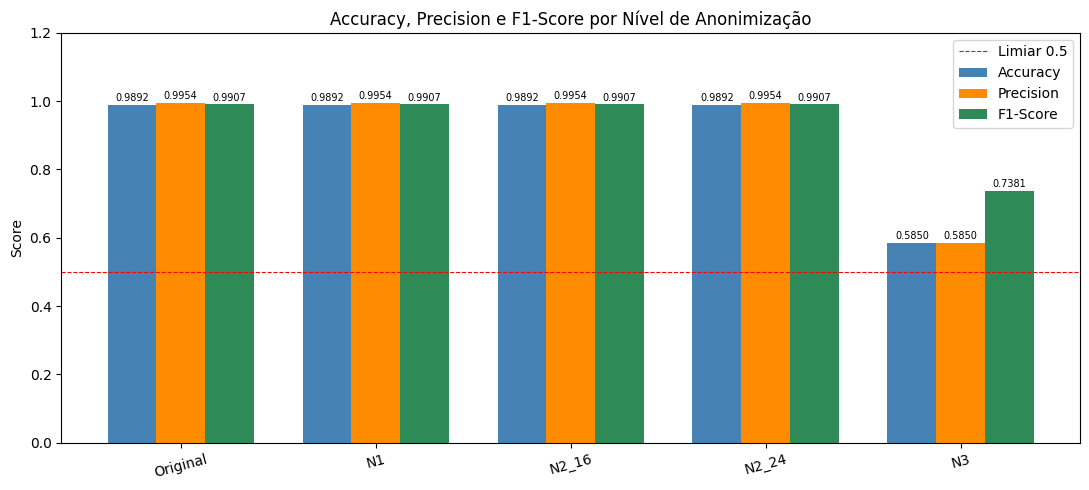

In [27]:
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(df_results))
width  = 0.25
labels = df_results["Dataset"]

b1 = ax.bar(x - width, df_results["Accuracy"],  width, label="Accuracy",  color="steelblue")
b2 = ax.bar(x,         df_results["Precision"], width, label="Precision", color="darkorange")
b3 = ax.bar(x + width, df_results["F1-Score"],  width, label="F1-Score",  color="seagreen")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score")
ax.set_title("Accuracy, Precision e F1-Score por Nível de Anonimização")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Limiar 0.5")
ax.legend()
plt.tight_layout()
plt.savefig("classifier_metrics.png", dpi=150)
plt.show()

/tmp/ipykernel_6807/736995148.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(ip_dists.values(), labels=ip_dists.keys(), patch_artist=True)


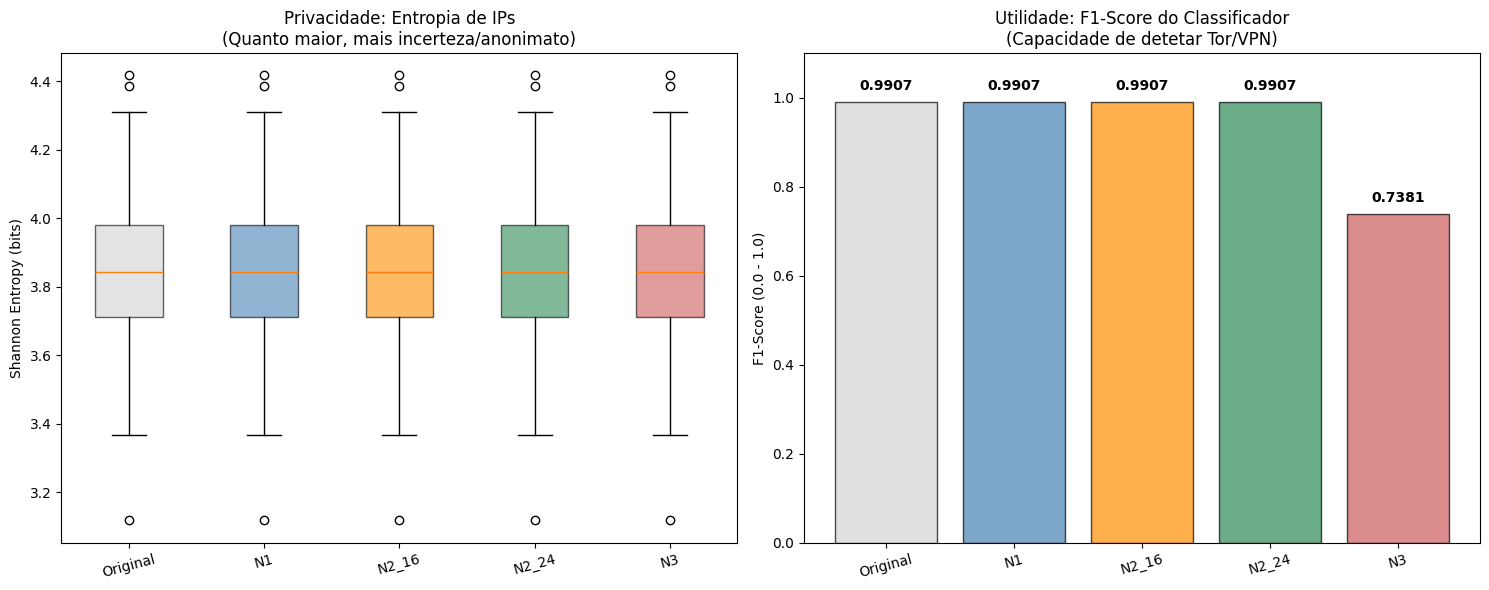

In [28]:
def get_distribution(data, n_samples=500, sample_size=100):
    rng = np.random.default_rng(42)
    values = np.array(data)
    if len(values) == 0: return [0] * n_samples
    
    dist = []
    for _ in range(n_samples):
        sample = rng.choice(values, size=min(sample_size, len(values)), replace=False)
        counts = Counter(sample)
        total = sum(counts.values())
        h = -sum((c/total) * math.log2(c/total) for c in counts.values())
        dist.append(h)
    return dist

f1_scores = dict(zip(df_results["Dataset"],df_results["F1-Score"]))

labels = ["Original", "N1", "N2_16", "N2_24", "N3"]
ip_dists = {}
for label in labels:
    if label in dfs:
        flag = 0 if label in ["Original", "N3"] else 1
        ips = get_src_ips(dfs[label], flag)
        ip_dists[label] = get_distribution(ips)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ["lightgrey", "steelblue", "darkorange", "seagreen", "indianred"]

bp1 = ax1.boxplot(ip_dists.values(), labels=ip_dists.keys(), patch_artist=True)
ax1.set_title("Privacidade: Entropia de IPs\n(Quanto maior, mais incerteza/anonimato)")
ax1.set_ylabel("Shannon Entropy (bits)")

for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

bars = ax2.bar(f1_scores.keys(), f1_scores.values(), color=colors, alpha=0.7, edgecolor='black')
ax2.set_title("Utilidade: F1-Score do Classificador\n(Capacidade de detetar Tor/VPN)")
ax2.set_ylabel("F1-Score (0.0 - 1.0)")
ax2.set_ylim(0, 1.1) 

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, yval, ha='center', va='bottom', fontweight='bold')

plt.setp(ax1.get_xticklabels(), rotation=15)
plt.setp(ax2.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.savefig("privacidade_vs_f1score.png", dpi=150)
plt.show()

### Relação Privacidade e Utilidade

O gŕafico abaixo reperesentado permite-nos perceber a relação entre o k médio e o *F1-Score* de cada dataset. Podemos concluir dos dados reperesentados que o melhor ponto em questão de tradeoff entre o a privacidade(k médio) e a utilidade (*F1-score*) está representado pelo nível N2_16, ou seja, o uso de *prefix-preserving* preservando apenas os primeiros 16 bits de um dado IP. A anonimização dos IPs não pode ser completa, como no caso do N1, pois isso diminui significativamente o número de grupos entre hosts tornando mais fácil a identificação de hosts individuais. A ofuscação e anonimização dos campos de aplicação pode também ser prejudicial para a utilidade das capturas, como podemos observar no N3, pois impede certos parâmetros de serem usados para identificação e especificação do tipo de tráfego de rede que se está a observar. Por fim vemos que o N2_16 é superior ao N2_24 apenas em relação á privacidade, uma vez que o uso de um prefixo grande pode dimnuir o número de hosts que podem pertencer a uma subnet, tornando-se assim mais fácil, estatísticamente, a identificação de um dado host.

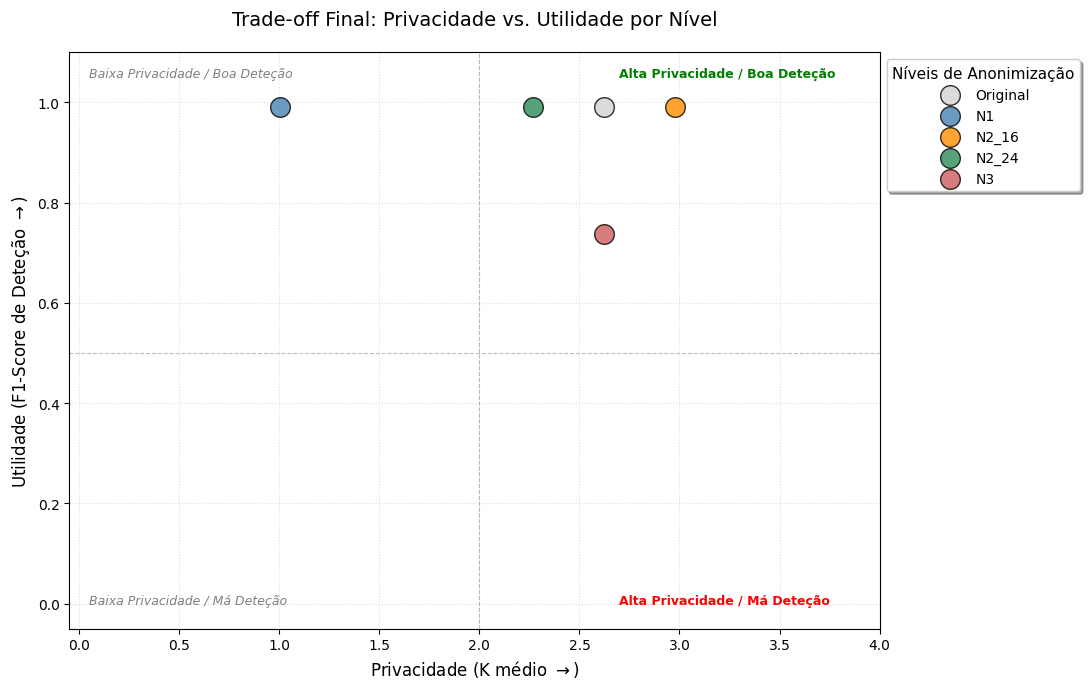

In [29]:
df_u = df_results[['Dataset', 'F1-Score']].rename(columns={'Dataset': 'ID'})
df_k_pivot = df_k.groupby("PCAP")["k (média)"].mean().reset_index()
df_k_pivot.columns = ["ID", "k médio"]
df_k_tradeoff = pd.merge(df_u, df_k_pivot, on='ID')

fig, ax = plt.subplots(figsize=(11, 7))

colors_map = {
    "Original": "#d3d3d3",
    "N1":       "#4682b4",
    "N2_16":    "#ff8c00",
    "N2_24":    "#2e8b57",
    "N3":       "#cd5c5c"
}

for i, row in df_k_tradeoff.iterrows():
    label = row["ID"]
    color = colors_map.get(label, "black")
    
    ax.scatter(row["k médio"], row["F1-Score"], 
               s=200, color=color, alpha=0.8, edgecolors="black", 
               label=label, zorder=5)

ax.axvline(2, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

ax.text(0.05, 0.00, "Baixa Privacidade / Má Deteção", fontsize=9, color="gray", style='italic')
ax.text(0.05, 1.05, "Baixa Privacidade / Boa Deteção", fontsize=9, color="gray", style='italic')
ax.text(2.70, 1.05, "Alta Privacidade / Boa Deteção",  fontsize=9, color="green", fontweight='bold')
ax.text(2.70, 0.00, "Alta Privacidade / Má Deteção",   fontsize=9, color="red", fontweight='bold')

ax.set_xlabel("Privacidade (K médio $\\rightarrow$)", fontsize=12)
ax.set_ylabel("Utilidade (F1-Score de Deteção $\\rightarrow$)", fontsize=12)
ax.set_title("Trade-off Final: Privacidade vs. Utilidade por Nível", fontsize=14, pad=20)

ax.set_xlim(-0.05, 4)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, linestyle=':', alpha=0.4)

ax.legend(title="Níveis de Anonimização", title_fontsize='11', 
          loc='upper left', bbox_to_anchor=(1, 1), 
          frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("privacy_utility_tradeoff_legend.png", dpi=150, bbox_inches='tight')
plt.show()